# 04 — 板块波动率贡献河流图

本 Notebook 展示各板块对正式板块等权市场年化波动率的结构性贡献。贡献占比同时考虑板块级线性 ramp-in 权重，每个月合计为 100%；图中无效板块在该月不占贡献。

## 统计口径

- 每个板块的波动率沿用正式分析中的三个月滚动窗口和 252 个交易日年化口径；板块内新品种和新板块按六个月线性 ramp-in。
- 每月板块贡献占比 = 板块 ramp-in 权重 × 板块年化波动率 ÷ 当月全部有效板块加权波动率之和。
- 河流图采用零基线堆叠，纵轴为贡献占比；所有有效月份拼接在同一张图中，无效板块按 0 处理。
- 历史不足状态阈值不影响本图的可用月份。

In [1]:
# ruff: noqa: E402, E501
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config" / "config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from cta_research import (
    build_sector_research_context,
    compute_sector_volatility_contribution_shares,
    plot_sector_volatility_river,
)

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = (
    "PingFang SC",
    "Noto Sans CJK SC",
    "Noto Sans CJK JP",
    "Microsoft YaHei",
    "SimHei",
    "Heiti SC",
    "STHeiti",
    "Arial Unicode MS",
    "DejaVu Sans",
)
plot_font = next((font for font in font_candidates if font in available_fonts), "DejaVu Sans")
plt.rcParams.update({"figure.dpi": 110, "font.family": plot_font, "axes.unicode_minus": False})

In [2]:
context = build_sector_research_context(PROJECT_ROOT / "config" / "config.yaml", PROJECT_ROOT)
contributions = compute_sector_volatility_contribution_shares(
    context.environment_result.volatility_by_month,
    context.ramp_in_result.member_weights_by_month,
)
monthly_totals = contributions.sum(axis=1)
assert np.allclose(monthly_totals.to_numpy(), 1.0)

summary = pd.Series(
    {
        "商品数据起止": f"{context.dominant_prices['date'].min().date()} — {context.dominant_prices['date'].max().date()}",
        "贡献占比起止": f"{contributions.index.min().date()} — {contributions.index.max().date()}",
        "板块数": contributions.shape[1],
        "有效月份数": contributions.shape[0],
        "每月贡献合计": "100%",
    },
    name="value",
)
display(summary.to_frame())

,value
商品数据起止,2011-07-01 — 2026-08-03
贡献占比起止,2011-09-30 — 2026-07-31
板块数,11
有效月份数,179
每月贡献合计,100%


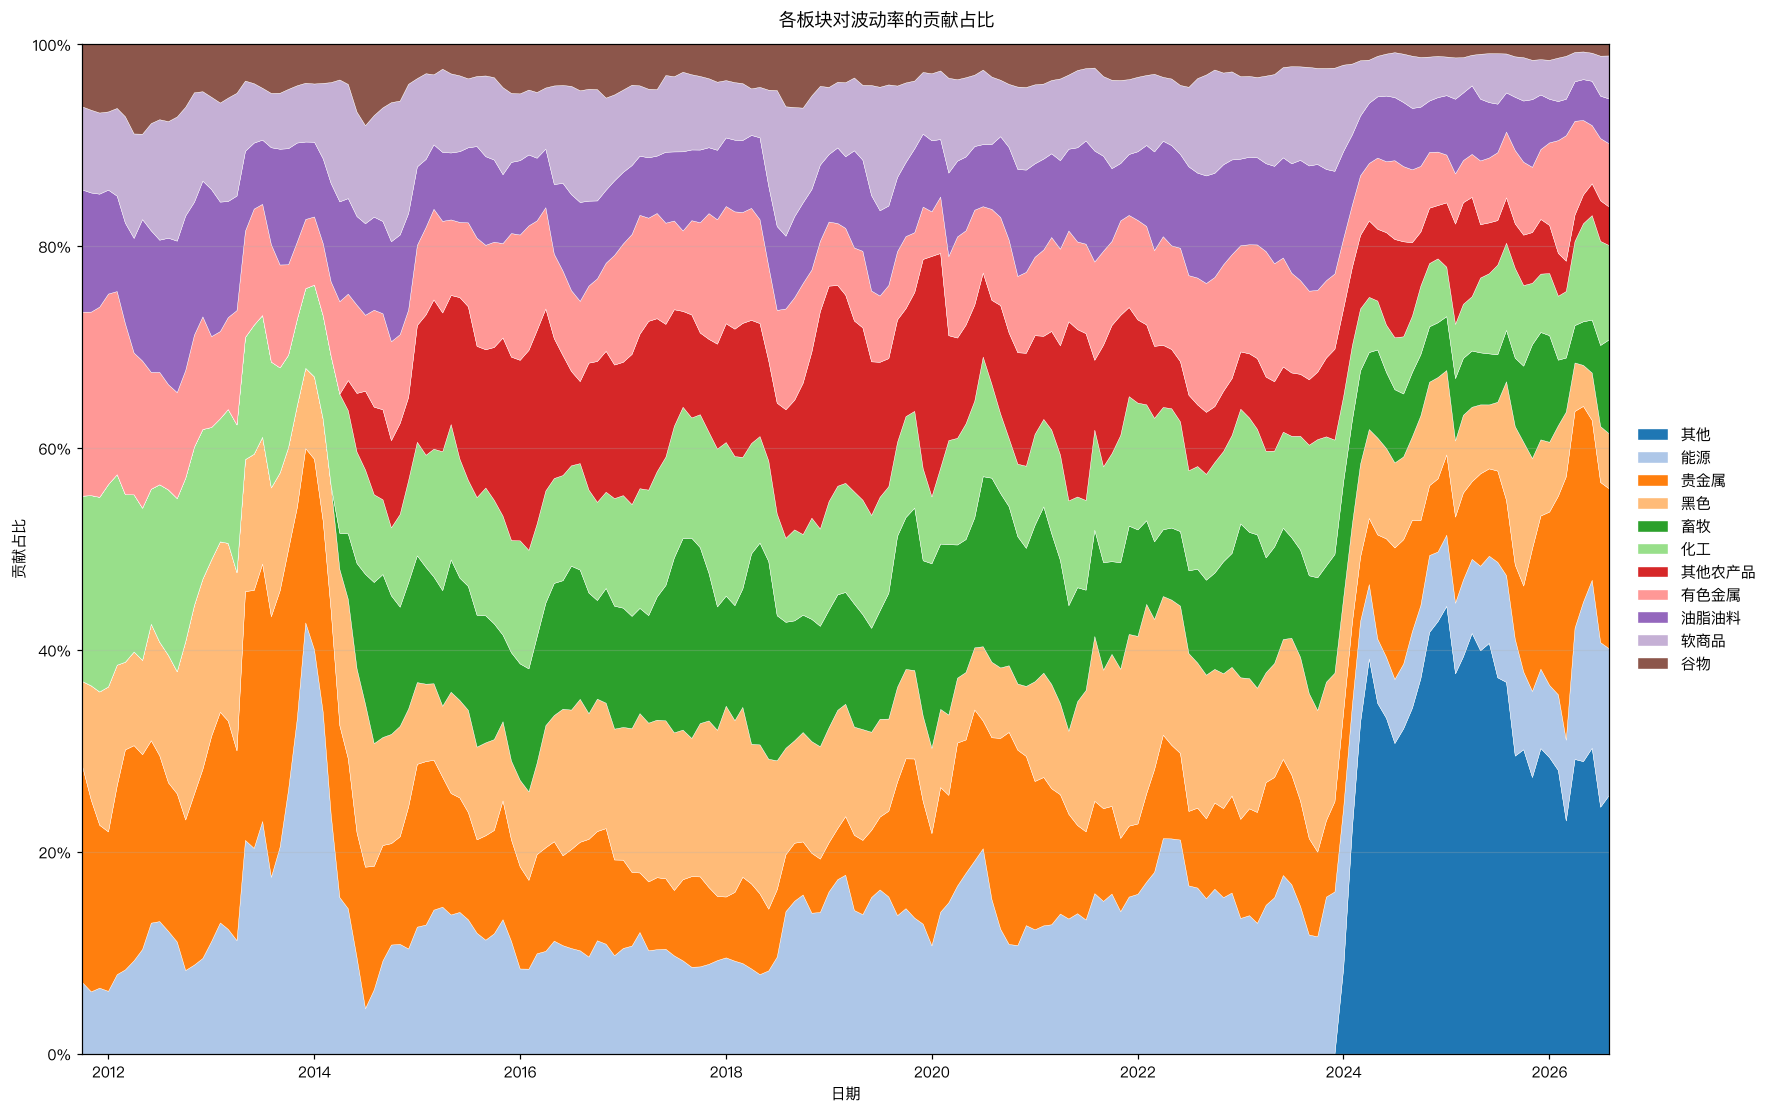

In [3]:
figure = plot_sector_volatility_river(contributions)
display(figure)
figure.savefig(FIGURES_DIR / "sector_volatility_contribution_river.png", dpi=150, bbox_inches="tight")
plt.close(figure)

In [4]:
latest_contributions = (
    contributions.iloc[-1]
    .dropna()
    .sort_values(ascending=False)
    .rename("贡献占比")
    .to_frame()
)
display(latest_contributions.style.format({"贡献占比": "{:.2%}"}))

,贡献占比
其他,25.64%
贵金属,15.84%
能源,14.51%
畜牧,9.33%
化工,9.33%
有色金属,6.27%
黑色,5.45%
油脂油料,4.44%
软商品,4.27%
其他农产品,3.81%
